Project Title 
- IPL data Analysis Performance Insights 2025 


- Project Objective
    - This project aims to perform Exploratory data analysis(EDA)
    - on IPL dataset to identify team performance, player performance,
    - match results, winning patterns, toss impact and other key insights.

Business Problem: 
    - IPL generates huge amounts of match data every season. 
        - Number of matches played 
        - winning teams 
        - Run scored by players 
        - Wickets taken by bowlers 
        - Toss winners 
        - match venues 
        - match scores 
    - Teams, coaches, analysts and management need insights from this data to make better strategic decisions. 
    
    - However, due to the large volume of data, it becomes difficult to manually identify winning patterns, player 
      performance trends, toss impact and venue advantages. 

    - Therefore, Exploratory Data Analysis(EDA) is performed to convert row IPL data into meaningful insights that support 
      data driven decisions.
        

- Importing required libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns  

import warnings 
warnings.filterwarnings("ignore") 


- loading IPL dataset

In [2]:
 ipl_data = pd.read_csv(r"C:\Users\Acss\Downloads\merged_ipl_data.csv") 
 ipl_data.head()

,match_id,date,player_team,striker,batting_position,balls_faced,runs_scored,strike_rate,dots,singles,...,bowler,runs_conceded,wickets_taken,dots_bowled,fours_conceded,sixes_conceded,bowling_team,opposition_team,overs_bowled,economy_rate
0,202501,2025-03-22,KKR,de Kock,1.0,5.0,4.0,80.000000,4.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,202501,2025-03-22,KKR,Rahane,2.0,31.0,56.0,180.645161,14.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,202501,2025-03-22,KKR,Narine,3.0,26.0,44.0,169.230769,13.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,202501,2025-03-22,KKR,Venkatesh Iyer,4.0,7.0,6.0,85.714286,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,202501,2025-03-22,KKR,Angkrish Raghuvanshi,5.0,22.0,30.0,136.363636,4.0,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Dataset Understanding

In [3]:
# checking dataset shape 
s = ipl_data.shape
print(f'this data contains {s[0]} rows and {s[1]} columns')

this data contains 1997 rows and 36 columns


In [22]:
# checking columns 
ipl_data.columns 

Index(['match_id', 'date', 'player_team', 'striker', 'batting_position',
       'balls_faced', 'runs_scored', 'strike_rate', 'dots', 'singles',
       'doubles', 'triples', 'fours', 'fives', 'sixes', 'dismissal_type',
       'date_match', 'venue', 'team1', 'team2', 'stage', 'match_winner',
       'player_of_the_match', 'margin', 'record_type', 'innings', 'bowler',
       'runs_conceded', 'wickets_taken', 'dots_bowled', 'fours_conceded',
       'sixes_conceded', 'bowling_team', 'opposition_team', 'overs_bowled',
       'economy_rate'],
      dtype='str')

In [23]:
#checking data types 
ipl_data.dtypes

match_id                 int64
date                       str
player_team                str
striker                    str
batting_position       float64
balls_faced            float64
runs_scored            float64
strike_rate            float64
dots                   float64
singles                float64
doubles                float64
triples                float64
fours                  float64
fives                  float64
sixes                  float64
dismissal_type             str
date_match                 str
venue                      str
team1                      str
team2                      str
stage                      str
match_winner               str
player_of_the_match        str
margin                     str
record_type                str
innings                float64
bowler                     str
runs_conceded          float64
wickets_taken          float64
dots_bowled            float64
fours_conceded         float64
sixes_conceded         float64
bowling_

In [26]:
ipl_data.isnull().sum()

match_id                  0
date                      6
player_team             870
striker                 870
batting_position        870
balls_faced             870
runs_scored             870
strike_rate             870
dots                    870
singles                 870
doubles                 870
triples                 870
fours                   870
fives                   870
sixes                   870
dismissal_type          870
date_match              872
venue                     8
team1                     8
team2                     8
stage                     8
match_winner             38
player_of_the_match      38
margin                   70
record_type               0
innings                1127
bowler                 1127
runs_conceded          1127
wickets_taken          1127
dots_bowled            1127
fours_conceded         1127
sixes_conceded         1127
bowling_team           1127
opposition_team        1127
overs_bowled           1127
economy_rate        

## comments
    - missing values and duplicates can affect analysis, 
    - therefore they should be identified and treated.

## statistical summary 

In [26]:
ipl_data.describe()

,match_id,batting_position,balls_faced,runs_scored,strike_rate,dots,singles,doubles,triples,fours,fives,sixes,innings,runs_conceded,wickets_taken,dots_bowled,fours_conceded,sixes_conceded,overs_bowled,economy_rate
count,1997.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,870.000000,870.000000,870.000000,870.000000,870.000000,870.000000,870.000000,870.000000
mean,202536.954432,4.697427,14.656610,22.377107,131.978890,4.950311,5.669033,0.858917,0.024845,2.001775,0.001775,1.149956,1.506897,30.451724,1.003448,6.137931,2.621839,1.489655,3.151034,9.996084
std,21.575041,2.716279,12.727926,23.091769,78.074885,3.929125,5.907633,1.246155,0.161323,2.412224,0.042108,1.641399,0.509358,12.258131,1.043909,3.310451,1.753046,1.318806,1.028721,3.747506
min,202501.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.100000,2.000000
25%,202518.000000,2.000000,5.000000,4.000000,83.333333,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,22.000000,0.000000,4.000000,1.000000,0.000000,2.300000,7.500000
50%,202536.000000,4.000000,11.000000,15.000000,133.333333,4.000000,4.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,30.000000,1.000000,6.000000,2.000000,1.000000,3.750000,9.666667
75%,202556.000000,7.000000,21.500000,34.000000,178.319624,7.000000,8.000000,1.000000,0.000000,3.000000,0.000000,2.000000,2.000000,39.000000,2.000000,8.000000,4.000000,2.000000,4.000000,11.750000
max,202574.000000,11.000000,65.000000,141.000000,600.000000,21.000000,30.000000,8.000000,2.000000,14.000000,1.000000,11.000000,4.000000,80.000000,6.000000,17.000000,10.000000,7.000000,4.100000,54.000000


## comment 
- statistical summary provides mean, 
 median, minimum, maximum and standard deviation.

## Business Questions, Analysis, and Insights
    - The following section presents important business questions 
       extracted from the IPL dataset. Each question is answered
       through Exploratory Data Analysis (EDA), supported by
       visualizations and data-driven insights. 

 ##  Question 1. Which team won the most matches in IPL history? 

In [3]:
team_wins = ipl_data['match_winner'].value_counts() 
team_wins.head(10)

match_winner
PBKS    301
RCB     269
GT      243
DC      227
MI      217
SRH     170
LSG     160
KKR     142
CSK     119
RR      111
Name: count, dtype: int64

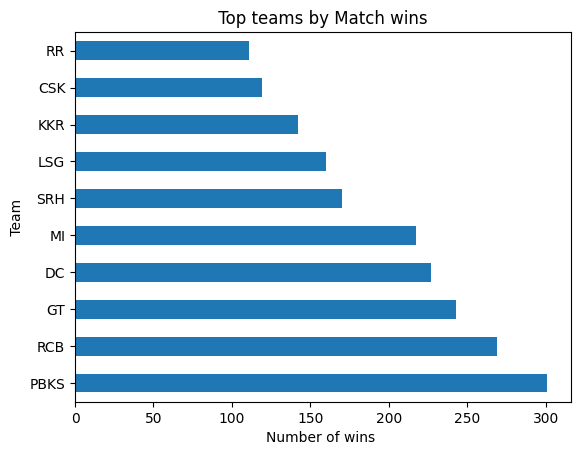

In [4]:
team_wins.head(10).plot(kind = 'barh') 
plt.title(" Top teams by Match wins ") 
plt.xlabel("Number of wins ") 
plt.ylabel(" Team ") 
plt.show() 

## Insight 
    - This chart identifies the most successful IPL teams 
      based on total matches won. 

# Questions.2 which players scored the highest number of runs?

In [12]:
top_run = ipl_data.groupby('striker')['runs_scored'].sum().sort_values(
    ascending=False) 
top_run.head(10)

striker
Sai Sudharsan       759.0
Suryakumar Yadav    717.0
Kohli               657.0
Shubman Gill        649.0
Mitchell Marsh      627.0
Shreyas Iyer        603.0
Prabhsimran         598.0
Jaiswal             559.0
Rahul               546.0
Priyansh Arya       545.0
Name: runs_scored, dtype: float64

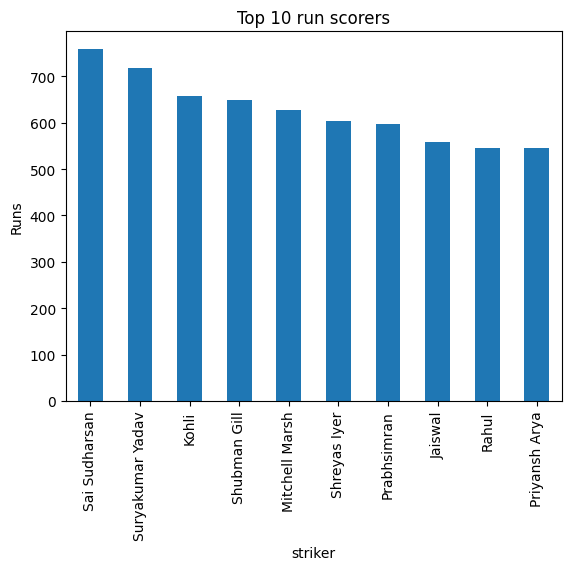

In [18]:
top_run.head(10).plot(kind='bar') 
plt.title("Top 10 run scorers") 
plt.ylabel("Runs")
plt.show() 

## Insight 
    Show the highest run scorers in the dataset. 

## Questions 3: Which bowler took the most wickets? 

In [22]:
top_wickets = ipl_data.groupby('bowler')["wickets_taken"].sum().sort_values(ascending=False) 
top_wickets.head(10) 

bowler
Prasidh           26.0
Noor Ahmad        24.0
Boult             23.0
Hazlewood         22.0
Arshdeep Singh    22.0
Bumrah            21.0
Vaibhav Arora     19.0
Mitchell Starc    19.0
Sai Kishore       19.0
Bhuvneshwar       18.0
Name: wickets_taken, dtype: float64

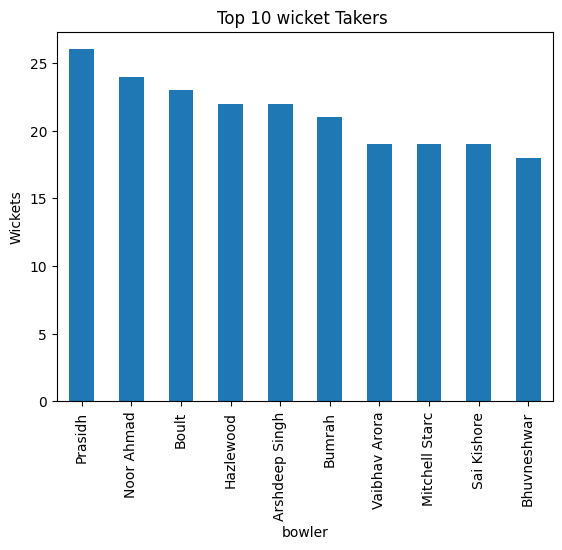

In [25]:
top_wickets.head(10).plot(kind='bar') 
plt.title("Top 10 wicket Takers ") 
plt.ylabel('Wickets') 
plt.show() 

## Insight 
    Identifies the most successful wicket_taking bowlers.

## Questions 4. Which IPL venue hosted the highest number of matches?

In [27]:
venues = ipl_data['venue'].value_counts() 
venues.head(10)

venue
Narendra Modi Stadium, Ahmedabad                 253
Ekana Cricket Stadium, Lucknow                   209
Wankhede Stadium, Mumbai                         199
Arun Jaitley Stadium, Delhi                      197
Eden Gardens, Kolkata                            179
Sawai Mansingh Stadium, Jaipur                   177
MA Chidambaram Stadium, Chennai                  175
New PCA Cricket Stadium, Mullanpur               168
Rajiv Gandhi International Stadium, Hyderabad    150
M. Chinnaswamy Stadium, Bangalore                136
Name: count, dtype: int64

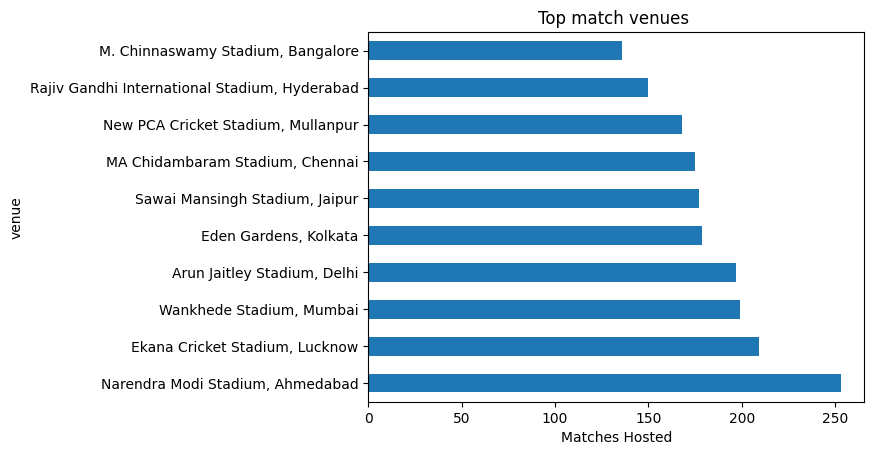

In [28]:
venues.head(10).plot(kind = 'barh') 
plt.title("Top match venues ") 
plt.xlabel("Matches Hosted") 
plt.show()

## Insight 
    - show the most frequently used IPL venues.

## Question 5. which team has the highest win percentage ?

In [37]:
matches_played = pd.concat(
    [ipl_data['team1'], 
    ipl_data["team2"]]
).value_counts() 

matches_won = ipl_data['match_winner'].value_counts()
win_pct = (matches_won / matches_played)* 100 
win_pct.sort_values(
    ascending = False
).head(10) 

match_winner
PBKS    66.445916
RCB     66.093366
DC      60.212202
GT      60.148515
MI      48.329621
SRH     44.854881
LSG     42.553191
KKR     40.571429
CSK     29.899497
RR      28.831169
Name: count, dtype: float64

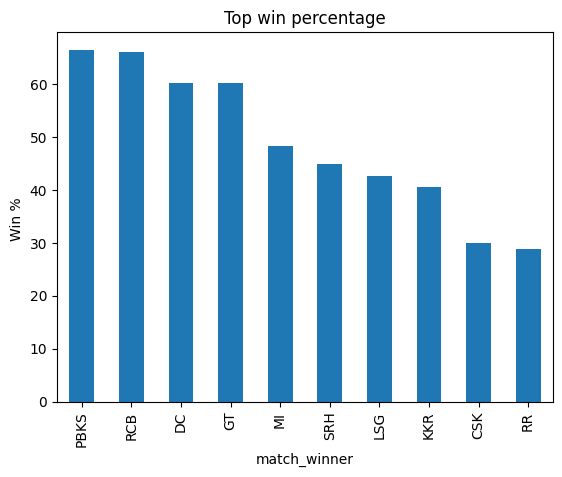

In [38]:
win_pct.sort_values(
    ascending=False
).head(10).plot(kind='bar') 
plt.title("Top win percentage") 
plt.ylabel("Win % ") 
plt.show() 

## Question 6. which players hit the highest number of sixes?

In [6]:
# Total sixes by each player 
top_sixes = ipl_data.groupby('striker')['sixes'].sum().sort_values(ascending=False) 
top_sixes.head(10) 

striker
Pooran              40.0
Shreyas Iyer        39.0
Suryakumar Yadav    38.0
Mitchell Marsh      37.0
Priyansh Arya       31.0
Prabhsimran         30.0
Abhishek Sharma     28.0
Jaiswal             28.0
Riyan Parag         27.0
Klaasen             25.0
Name: sixes, dtype: float64

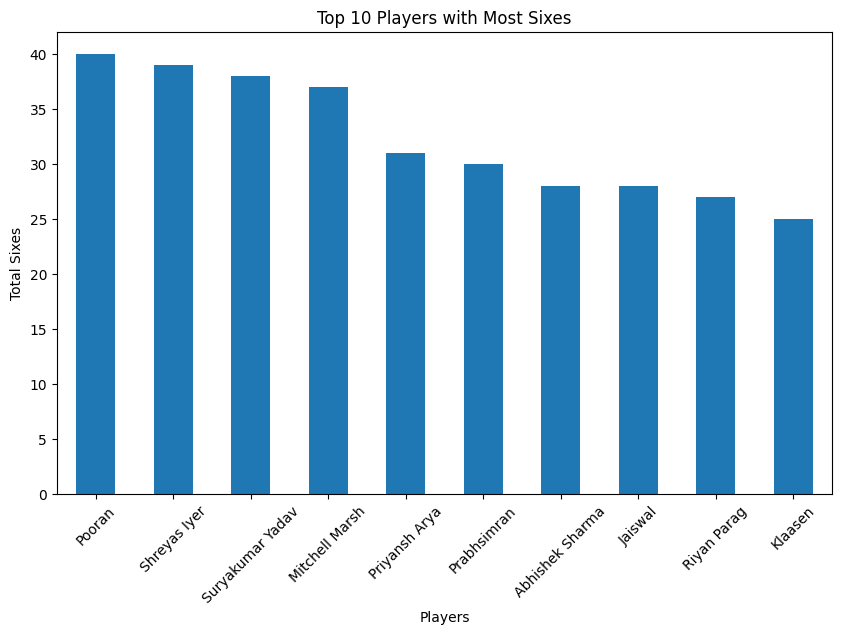

In [7]:
plt.figure(figsize=(10,6))

top_sixes.head(10).plot(kind='bar')

plt.title("Top 10 Players with Most Sixes")
plt.xlabel("Players")
plt.ylabel("Total Sixes")

plt.xticks(rotation=45)

plt.show()

## insight 

The chart shows the top 10 players who have hit the highest number of sixes in IPL history.

These players are aggressive batsmen and play an important role in increasing the team's scoring rate.

## Question 7.Which bowlers have the best economy by conceding fewer runs?

In [9]:
best_bowlers = (
    ipl_data.groupby('bowler')['economy_rate']
    .mean()
    .sort_values()
)

best_bowlers.head(10) 

bowler
Naman Dhir             6.500000
Anukul Roy             6.750000
Bumrah                 6.758333
Unadkat                7.499300
N Thushara             7.500000
Kuldeep Yadav          7.678571
Mustafizur             7.916667
Varun Chakaravarthy    7.923077
Narine                 8.027778
Maxwell                8.027778
Name: economy_rate, dtype: float64

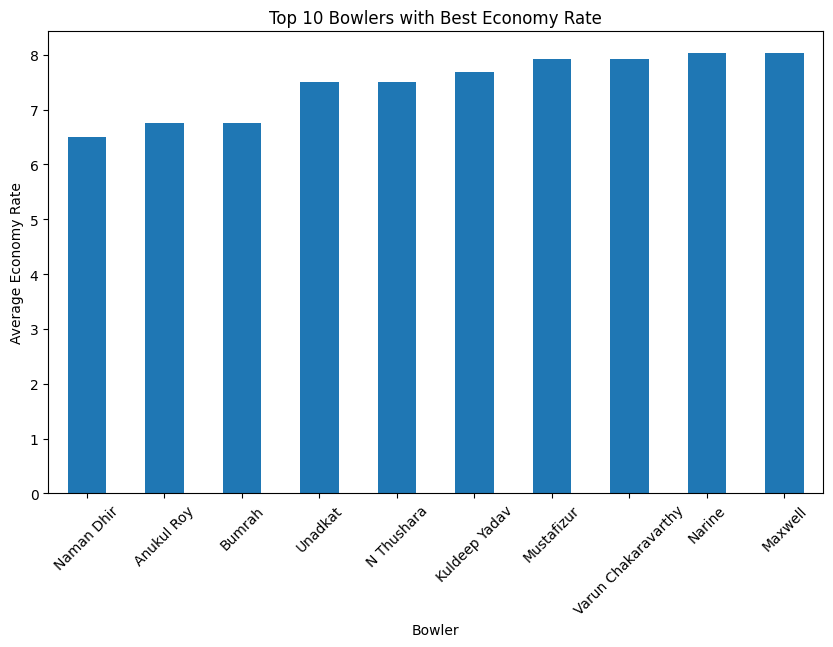

In [10]:
plt.figure(figsize=(10,6))

best_bowlers.head(10).plot(kind='bar')

plt.title("Top 10 Bowlers with Best Economy Rate")
plt.xlabel("Bowler")
plt.ylabel("Average Economy Rate")

plt.xticks(rotation=45)

plt.show()

## Question 8. Which players hit the most fours? 

In [11]:
top_fours = (
    ipl_data.groupby('striker')['fours']
    .sum()
    .sort_values(ascending=False)
)

top_fours.head(10) 

striker
Sai Sudharsan       88.0
Suryakumar Yadav    69.0
Kohli               66.0
Prabhsimran         63.0
Shubman Gill        62.0
Jaiswal             60.0
Priyansh Arya       60.0
Mitchell Marsh      56.0
Rahul               53.0
Buttler             52.0
Name: fours, dtype: float64

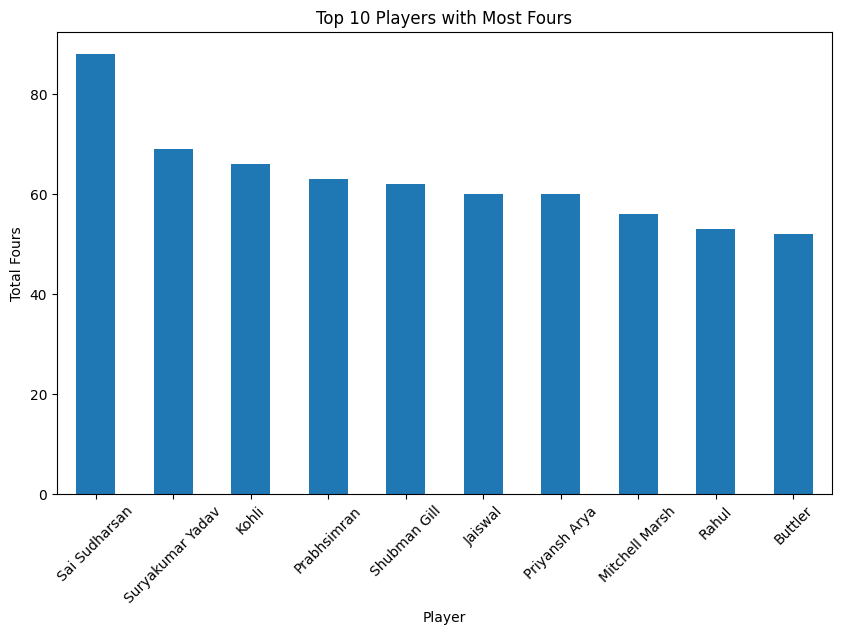

In [12]:
plt.figure(figsize=(10,6))

top_fours.head(10).plot(kind='bar')

plt.title("Top 10 Players with Most Fours")
plt.xlabel("Player")
plt.ylabel("Total Fours")

plt.xticks(rotation=45)

plt.show() 

## Question 9. Which batting positions scored the most runs?

In [13]:
batting_position = (
    ipl_data.groupby('batting_position')['runs_scored']
    .sum()
    .sort_values(ascending=False)
)

batting_position 

batting_position
2.0     5215.0
1.0     4383.0
3.0     4308.0
4.0     3616.0
5.0     2906.0
6.0     2103.0
7.0     1505.0
8.0      689.0
9.0      341.0
10.0     114.0
11.0      39.0
Name: runs_scored, dtype: float64

## Question 10. Which bowlers took the most dot balls? 

In [14]:
dot_balls = (
    ipl_data.groupby('bowler')['dots_bowled']
    .sum()
    .sort_values(ascending=False)
)

dot_balls.head(10) 

bowler
Siraj                  141.0
Prasidh                135.0
Arshdeep Singh         134.0
Khaleel Ahmed          131.0
Bumrah                 125.0
Boult                  124.0
Hazlewood              117.0
Bhuvneshwar            116.0
Varun Chakaravarthy    114.0
Cummins                111.0
Name: dots_bowled, dtype: float64

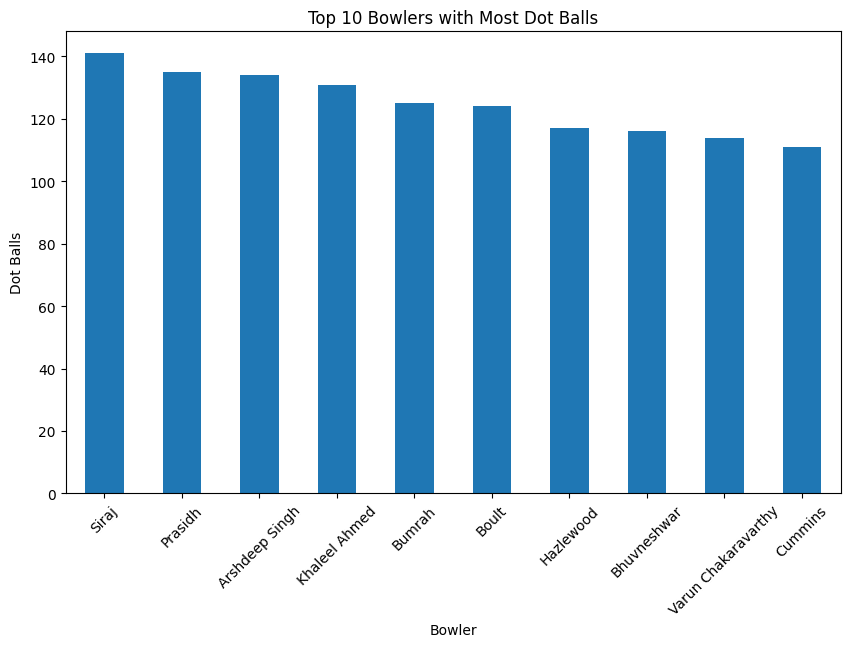

In [15]:
plt.figure(figsize=(10,6))

dot_balls.head(10).plot(kind='bar')

plt.title("Top 10 Bowlers with Most Dot Balls")
plt.xlabel("Bowler")
plt.ylabel("Dot Balls")

plt.xticks(rotation=45)

plt.show()